# BikeFlow — Baseline Demand Forecasting

本 Notebook 用一个简单的 `LinearRegression` 模型，预测纽约 Citi Bike **每小时开始的骑行次数**（`ride_count`）。输入只包括日历时间和已有天气字段，不使用历史需求的 lag 或 rolling 特征。

**本次运行速览：**按时间前 80% 训练、后 20% 测试；测试集 MAE 为 2,039.15 次/小时、RMSE 为 2,722.81 次/小时、R² 为 0.513。工作日通勤高峰的需求仍被明显低估。

数据源是 `data/processed/bikeflow_2024.csv`。这是使用 2024 年历史天气观测进行的**回顾性 Baseline**；若要提前预测未来小时，同一时刻的气温、湿度和风速需要由天气预报提供。

## 1. Load Dataset

从项目已生成的最终建模 CSV 读取数据，并把 `timestamp` 解析为时间类型。路径同时支持从项目根目录或 `notebooks/` 目录运行。

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "processed" / "bikeflow_2024.csv").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "bikeflow_2024.csv"
if not DATA_PATH.exists():
    raise FileNotFoundError("请从 BikeFlow 项目根目录或 notebooks 目录运行")

data = pd.read_csv(DATA_PATH, parse_dates=["timestamp"])
print(f"读取文件: {DATA_PATH}")

读取文件: C:\Users\txy18\Desktop\BikeFlow\data\processed\bikeflow_2024.csv


## 2. Inspect Modeling Data

先看**维度**与**列名**，确认一行代表一个本地时钟小时标签；再看**前五行**，核对时间、目标和天气值是否符合预期。

In [2]:
print(f"数据维度（行, 列）: {data.shape}")
print(f"列名: {data.columns.tolist()}")
display(data.head())

数据维度（行, 列）: (8784, 10)
列名: ['timestamp', 'ride_count', 'temperature_2m', 'apparent_temperature', 'relative_humidity_2m', 'precipitation', 'rain', 'snowfall', 'weather_code', 'wind_speed_10m']


,timestamp,ride_count,temperature_2m,apparent_temperature,relative_humidity_2m,precipitation,rain,snowfall,weather_code,wind_speed_10m
0,2024-01-01 00:00:00,1901,1.8,-2.1,71.0,0.0,0.0,0.0,3.0,9.0
1,2024-01-01 01:00:00,2333,2.4,-1.7,71.0,0.0,0.0,0.0,3.0,10.9
2,2024-01-01 02:00:00,1939,2.4,-1.5,73.0,0.0,0.0,0.0,3.0,10.1
3,2024-01-01 03:00:00,1099,2.2,-1.4,75.0,0.0,0.0,0.0,1.0,8.1
4,2024-01-01 04:00:00,656,0.0,-3.2,87.0,0.0,0.0,0.0,2.0,5.6


**数据类型**可检查 `timestamp` 是否已解析、天气是否为数值；**缺失值**可提示哪些行不能直接交给线性回归。

In [3]:
column_check = pd.DataFrame({
    "dtype": data.dtypes.astype(str),
    "missing_count": data.isna().sum(),
    "missing_pct": (data.isna().mean() * 100).round(3),
})
column_check.index.name = "column"
display(column_check)
print(f"重复 timestamp 数: {data['timestamp'].duplicated().sum()}")
print(f"时间范围: {data['timestamp'].min()} 至 {data['timestamp'].max()}")

,dtype,missing_count,missing_pct
column,,,
timestamp,datetime64[us],0,0.000
ride_count,int64,0,0.000
temperature_2m,float64,1,0.011
apparent_temperature,float64,1,0.011
relative_humidity_2m,float64,1,0.011
precipitation,float64,1,0.011
rain,float64,1,0.011
snowfall,float64,1,0.011
weather_code,float64,1,0.011


重复 timestamp 数: 0
时间范围: 2024-01-01 00:00:00 至 2024-12-31 23:00:00


## 3. Feature Engineering

**预测目标**是 `ride_count`：某个纽约本地小时内开始的 Citi Bike 骑行次数。只从该小时的 `timestamp` 提取基础时间特征：

- `hour`：一天中的第几个小时，范围 0–23。
- `day_of_week`：星期几；pandas 使用 0 = Monday、…、6 = Sunday。
- `month`：月份，范围 1–12。
- `is_weekend`：周六、周日为 1，其余为 0。

源 CSV 有两个夏令时特殊标签：`2024-03-10 02:00` 在纽约并不存在，是天气缺失、需求为 0 的占位行；`2024-11-03 01:00` 合并了两个真实小时的骑行。为了让每条建模记录都对应**一个真实小时**，只排除这两行，不修改源 CSV。

In [4]:
SPRING_GAP = pd.Timestamp("2024-03-10 02:00")
FALL_REPEAT = pd.Timestamp("2024-11-03 01:00")
spring_row = data.loc[data["timestamp"].eq(SPRING_GAP)]
fall_row = data.loc[data["timestamp"].eq(FALL_REPEAT)]
assert len(spring_row) == len(fall_row) == 1
assert spring_row["ride_count"].iloc[0] == 0
assert spring_row.drop(columns=["timestamp", "ride_count"]).isna().all(axis=None)

model_data = data.loc[~data["timestamp"].isin([SPRING_GAP, FALL_REPEAT])].copy()

# 构造时间特征 (Time Features)
model_data["hour"] = model_data["timestamp"].dt.hour
model_data["day_of_week"] = model_data["timestamp"].dt.dayofweek
model_data["month"] = model_data["timestamp"].dt.month
model_data["is_weekend"] = model_data["day_of_week"].ge(5).astype(int)

time_features = ["hour", "day_of_week", "month", "is_weekend"]
print(f"排除夏令时特殊行后: {len(model_data):,} 个真实小时")
display(model_data[["timestamp", "ride_count", *time_features]].head())

排除夏令时特殊行后: 8,782 个真实小时


,timestamp,ride_count,hour,day_of_week,month,is_weekend
0,2024-01-01 00:00:00,1901,0,0,1,0
1,2024-01-01 01:00:00,2333,1,0,1,0
2,2024-01-01 02:00:00,1939,2,0,1,0
3,2024-01-01 03:00:00,1099,3,0,1,0
4,2024-01-01 04:00:00,656,4,0,1,0


下面自动检查**实际存在的天气列**及其缺失率。选择数值完整、含义清楚的 `temperature_2m`、`relative_humidity_2m`、`precipitation`、`wind_speed_10m`。

`precipitation[t]` 是时间标签 **t 之前一小时**的累计降水，可视为预测 t 小时时已经观察到的近期天气；它并非 t 小时内的降水。EDA 使用的 `precipitation_during_hour` 需要 t+1 的观测，只适合事后分析，不能在本预测任务中当作已知输入。

其他现有列暂不使用：`apparent_temperature` 与气温高度重复；`rain` 与总降水重复；`snowfall` 的非零小时很少；`weather_code` 虽是数字，却是类别编码，数值大小不代表等距的天气强度。

In [5]:
weather_candidates = [
    "temperature_2m", "apparent_temperature", "relative_humidity_2m",
    "precipitation", "rain", "snowfall", "weather_code", "wind_speed_10m",
]
available_weather = [name for name in weather_candidates if name in data.columns]
weather_check = pd.DataFrame({
    "dtype": data[available_weather].dtypes.astype(str),
    "missing_count": data[available_weather].isna().sum(),
    "missing_pct": (data[available_weather].isna().mean() * 100).round(3),
    "unique_values": data[available_weather].nunique(),
})
display(weather_check)

weather_features = [
    "temperature_2m", "relative_humidity_2m", "precipitation", "wind_speed_10m",
]
assert set(weather_features).issubset(available_weather)
assert all(pd.api.types.is_numeric_dtype(model_data[name]) for name in weather_features)
assert model_data[weather_features].notna().all(axis=None)
feature_columns = time_features + weather_features
print(f"最终模型特征: {feature_columns}")

,dtype,missing_count,missing_pct,unique_values
temperature_2m,float64,1,0.011,459
apparent_temperature,float64,1,0.011,540
relative_humidity_2m,float64,1,0.011,83
precipitation,float64,1,0.011,82
rain,float64,1,0.011,82
snowfall,float64,1,0.011,23
weather_code,float64,1,0.011,13
wind_speed_10m,float64,1,0.011,368


最终模型特征: ['hour', 'day_of_week', 'month', 'is_weekend', 'temperature_2m', 'relative_humidity_2m', 'precipitation', 'wind_speed_10m']


## 4. Train-Test Split

按 `timestamp` 排序，前 80% 的小时训练、后 20% 测试。这样测试集始终晚于训练集，更接近“用过去预测未来”。

时间序列不能随机切分：随机切分可能把 12 月的数据放进训练集，却用 10 月的数据测试。**未来数据泄漏**是指模型训练或输入中用了预测当时还不可能知道的信息，例如测试时段之后的骑行需求，或本小时结束后才知道的本小时累计降水。

In [6]:
# 按时间顺序划分训练集和测试集
model_data = model_data.sort_values("timestamp").reset_index(drop=True)
X = model_data[feature_columns]
y = model_data["ride_count"]
split_index = int(len(model_data) * 0.8)

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]
train_time = model_data["timestamp"].iloc[:split_index]
test_time = model_data["timestamp"].iloc[split_index:]

assert X.notna().all(axis=None) and y.notna().all()
assert train_time.max() < test_time.min()
print(f"Train: {len(X_train):,} 小时，{train_time.min()} 至 {train_time.max()}")
print(f"Test:  {len(X_test):,} 小时，{test_time.min()} 至 {test_time.max()}")

Train: 7,025 小时，2024-01-01 00:00:00 至 2024-10-19 17:00:00
Test:  1,757 小时，2024-10-19 18:00:00 至 2024-12-31 23:00:00


## 5. Linear Regression Baseline

第一版只使用 `sklearn.linear_model.LinearRegression`。先给模型训练集的特征 `X_train` 和目标 `y_train`，再用测试集特征 `X_test` 生成预测：

```text
时间 + 天气特征 X  →  每小时需求 y
        ↓ 按时间切分
X_train / y_train  →  model.fit()
X_test             →  model.predict()  →  y_pred
```

这个模型把各特征作为简单线性输入，因此可能无法完整表达早晚高峰或季节变化；它仍是学习完整流程的清晰起点。

In [7]:
# 训练 Linear Regression baseline
model = LinearRegression()
model.fit(X_train, y_train)

# 模型预测
y_pred = model.predict(X_test)
print(f"已生成 {len(y_pred):,} 个测试小时的预测值")

已生成 1,757 个测试小时的预测值


## 6. Model Evaluation

- **MAE**（平均绝对误差）：预测值平均偏离真实值多少，单位是每小时骑行次数；越小越好。
- **RMSE**（均方根误差）：对较大误差更加敏感，单位同样是每小时骑行次数；越小越好。
- **R²**（决定系数）：模型对测试集需求变化的解释程度；1 表示完全吻合，0 相当于只预测测试集平均值，也可能小于 0。

In [8]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:,.2f} rides/hour")
print(f"RMSE: {rmse:,.2f} rides/hour")
print(f"R²:   {r2:.3f}")

MAE:  2,039.15 rides/hour
RMSE: 2,722.81 rides/hour
R²:   0.513


**结果解读：**测试集中，预测每小时平均偏差约 **2,039 次**；较大误差使 RMSE 升至约 **2,723 次**。R² 为 **0.513**，说明这个简单模型能解释测试集约一半的变化，但还不能准确跟上所有高峰。

## 7. Actual vs Predicted

选取测试集开头**连续 7 天**，对比每小时真实需求和预测需求。横轴是纽约本地时间，纵轴是每小时开始的骑行次数。

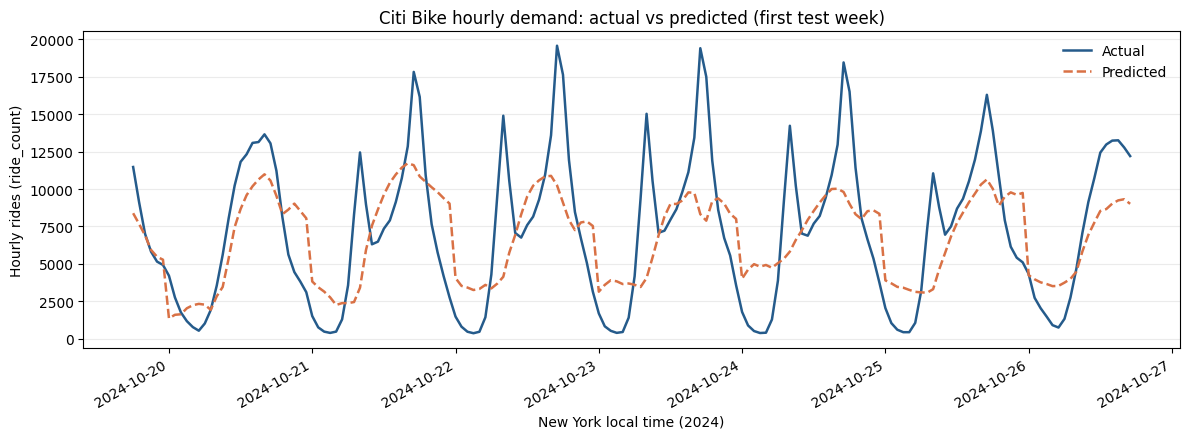

In [9]:
results = pd.DataFrame({
    "timestamp": test_time.to_numpy(),
    "actual": y_test.to_numpy(),
    "predicted": y_pred,
})
one_week = results.loc[
    results["timestamp"] < results["timestamp"].min() + pd.Timedelta(days=7)
]

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(one_week["timestamp"], one_week["actual"],
        color="#255B8B", linewidth=1.8, label="Actual")
ax.plot(one_week["timestamp"], one_week["predicted"],
        color="#D97145", linestyle="--", linewidth=1.8, label="Predicted")
ax.set(title="Citi Bike hourly demand: actual vs predicted (first test week)",
       xlabel="New York local time (2024)", ylabel="Hourly rides (ride_count)")
ax.grid(axis="y", alpha=0.25)
ax.legend(frameon=False)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

**图后观察：**这一周里，预测曲线大致跟随昼夜起伏，但几个工作日早晚高峰明显偏低，夜间低需求则常被高估。下节用误差表量化这两个现象。

## 8. Error Analysis

定义 `prediction_error = actual - predicted`：正值表示模型**低估**，负值表示**高估**。先看绝对误差最大的小时，再比较工作日、周末和工作日通勤高峰。线性回归也可能给出负的需求预测；这里保留原始预测来如实评价模型，不在测试集上临时裁剪。

In [10]:
results["prediction_error"] = results["actual"] - results["predicted"]
results["absolute_error"] = results["prediction_error"].abs()

print("绝对误差最大的 8 个小时：")
display(results.nlargest(8, "absolute_error")[[
    "timestamp", "actual", "predicted", "prediction_error", "absolute_error"
]].round({"predicted": 1, "prediction_error": 1, "absolute_error": 1}))
print(f"负预测值小时数: {(results['predicted'] < 0).sum()}")

绝对误差最大的 8 个小时：


,timestamp,actual,predicted,prediction_error,absolute_error
254,2024-10-30 08:00:00,15011,2457.5,12553.5,12553.5
230,2024-10-29 08:00:00,14301,1843.5,12457.5,12457.5
278,2024-10-31 08:00:00,14180,3056.4,11123.6,11123.6
95,2024-10-23 17:00:00,19412,8317.1,11094.9,11094.9
86,2024-10-23 08:00:00,15027,4050.3,10976.7,10976.7
62,2024-10-22 08:00:00,14900,4132.4,10767.6,10767.6
239,2024-10-29 17:00:00,17284,6562.0,10722.0,10722.0
206,2024-10-28 08:00:00,11970,1877.7,10092.3,10092.3


负预测值小时数: 51


这里把**工作日 07:00–09:00 和 16:00–19:00** 定为通勤高峰。分组表中的 `mean_error` 仍按“真实 − 预测”计算：正值表示平均低估，负值表示平均高估。`MAE` 则只看偏离幅度。

In [11]:
results["is_weekend"] = results["timestamp"].dt.dayofweek.ge(5)
results["hour"] = results["timestamp"].dt.hour
results["day_type"] = np.where(results["is_weekend"], "Weekend", "Weekday")
results["period"] = np.where(
    ~results["is_weekend"] & results["hour"].isin([7, 8, 9, 16, 17, 18, 19]),
    "Weekday commute hours", "Other hours",
)

day_errors = results.groupby("day_type").agg(
    hours=("actual", "size"), MAE=("absolute_error", "mean"),
    mean_error=("prediction_error", "mean"),
).reindex(["Weekday", "Weekend"])
peak_errors = results.groupby("period").agg(
    hours=("actual", "size"), mean_actual=("actual", "mean"),
    mean_predicted=("predicted", "mean"), MAE=("absolute_error", "mean"),
    mean_error=("prediction_error", "mean"),
).reindex(["Weekday commute hours", "Other hours"])

print("工作日与周末：")
display(day_errors.round(1))
print("工作日通勤高峰与其他小时：")
display(peak_errors.round(1))

工作日与周末：


,hours,MAE,mean_error
day_type,,,
Weekday,1248,2210.0,-49.6
Weekend,509,1620.2,-408.8


工作日通勤高峰与其他小时：


,hours,mean_actual,mean_predicted,MAE,mean_error
period,,,,,
Weekday commute hours,364,8308.8,5220.1,3467.3,3088.7
Other hours,1393,3620.4,4621.4,1666.0,-1000.9


**误差观察：**测试集工作日通勤高峰的真实均值约为 **8,309 次/小时**，预测均值约为 **5,220 次/小时**，平均低估约 **3,089 次**；其他小时平均高估约 **1,001 次**。最大的一次误差出现在 2024-10-30 08:00，低估约 **12,554 次**。另有 **51 个负预测值**，说明普通线性回归不会自动保证骑行次数非负。这些都是本 Baseline 的局限；分组平均误差可能互相抵消，所以也要看 MAE。

## 9. Next Step

下一阶段可在严格保持时间先后顺序的前提下，尝试历史需求特征：

- `lag_1`：上一小时需求。
- `lag_24`：昨天同一小时需求。
- `lag_168`：上周同一小时需求。

这些特征把最近的需求水平、每天和每周的重复规律直接告诉模型，可能明显改善早晚高峰的预测。不过构造时必须确保每一行只引用**预测时已经发生**的骑行，并留意夏令时特殊小时。本 Notebook 暂不加入 lag 或 rolling mean。